In [22]:
import pandas as pd
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv(r"E:\python\.newvenv\Data\Mall_Customer.csv")

In [24]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [34]:
# Remove duplicate values in Annual Income column (keep first occurrence)
df_no_duplicates = df.drop_duplicates(subset=['Annual Income (k$)'], keep='first')
print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame after removing duplicates: {df_no_duplicates.shape}")
print(f"Rows removed: {df.shape[0] - df_no_duplicates.shape[0]}")
print("\nFirst few rows:")
print(df_no_duplicates.head(10))

Original DataFrame shape: (200, 6)
DataFrame after removing duplicates: (64, 6)
Rows removed: 136

First few rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
2            3  Female   20                  16                       6   
4            5  Female   31                  17                      40   
6            7  Female   35                  18                       6   
8            9    Male   64                  19                       3   
12          13  Female   58                  20                      15   
16          17  Female   35                  21                      35   
18          19    Male   52                  23                      29   
20          21    Male   35                  24                      35   
22          23  Female   46                  25                       5   

    Newcluster  
0           -1  
2            1  
4       

In [26]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [27]:
model =  DBSCAN(eps=10,min_samples=8)

In [28]:
cluster = model.fit_predict(X)

In [30]:
df["Newcluster"] = cluster

In [31]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Newcluster  
0          -1  
1           0  
2           1  
3           0  
4          -1  


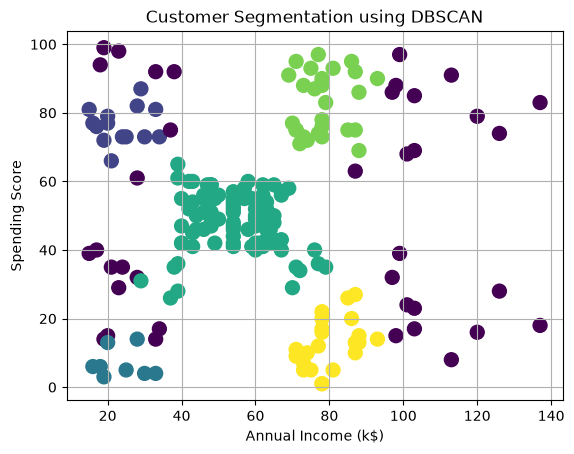

In [33]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=cluster,
    s=100
)
plt.title("Customer Segmentation using DBSCAN")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.grid(True)

plt.show()